In [1]:
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

import pulser
from pulser.waveforms import InterpolatedWaveform, CustomWaveform

import emu_sv
from emu_sv import SVConfig, SVBackend, Occupation, StateResult, StateVector, Fidelity

from pulse_counter_diabatic.counter_diabatic import CounterDiabaticPulse

from pulser import AnalogDevice

In [2]:
# ── DMRG ground-state helper ─────────────────────────────────────────────────
from emu_mps import (
    MPSBackend, MPSConfig, Solver, StateResult,
    Fidelity, Occupation, CorrelationMatrix, EntanglementEntropy, BitStrings
)

def dmrg_ground_state(seq):
    cfg = MPSConfig(with_modulation=False, dt=10, solver=Solver.DMRG, observables=[StateResult(evaluation_times=[1.0])])
    backend = MPSBackend(seq,config=cfg)
    result= backend.run() 
    target = result.final_state
    return target


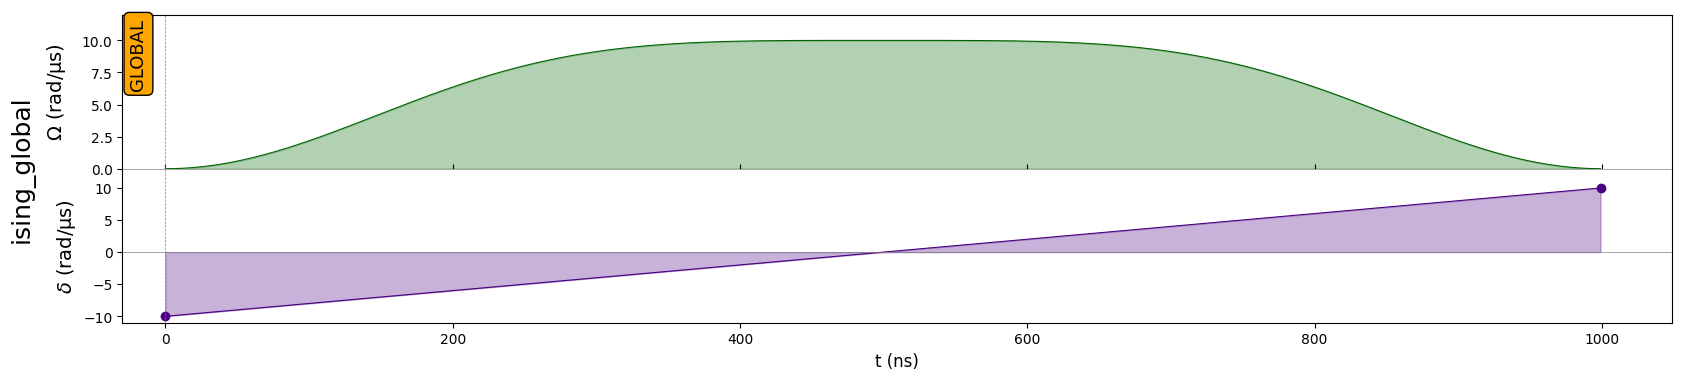

Atoms: 4
Duration: 1000 ns,  dt: 1 ns,  steps: 1000


In [5]:
n_side = 2
n_atoms = n_side * n_side
spacing = 7.0  

reg = pulser.Register.square(n_side, prefix="q", spacing=spacing)

# --- Bare adiabatic protocol ------------------------------------------------
# Ω(t) ≡ 0  →  pure detuning sweep
# δ(t) goes from -delta_max to +delta_max linearly
T = 1000          # total duration in ns
dt = 1           # emulation timestep in ns
delta_max = 10.0  # rad/μs (Pulser convention)
omega_max = 10.0   # required by the problem statement
C6= AnalogDevice.interaction_coeff

pulse_times = np.arange(T)                              
omega_samples = omega_max * np.sin(0.5 * np.pi * np.sin(np.pi * pulse_times / T)) ** 2
omega_wf = CustomWaveform(omega_samples)
adiabatic_pulse = pulser.Pulse(
    omega_wf,         # Ω(t) = 0
    InterpolatedWaveform(T, [-delta_max, delta_max]),         # δ ramp
    0.0,
)

seq = pulser.Sequence(reg, pulser.MockDevice)
seq.declare_channel("ising_global", "rydberg_global")
seq.add(adiabatic_pulse, "ising_global")
seq.draw()
print(f"Atoms: {n_atoms}")
print(f"Duration: {T} ns,  dt: {dt} ns,  steps: {T // dt}")

In [6]:
target=dmrg_ground_state(seq)

emu-mps allows only {'occupation', 'correlation_matrix', 'energy', 'bitstrings', 'energy_second_moment', 'statistics', 'energy_variance'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'state'} using `optimize_qubit_ordering = False` instead.
emu-mps allows only {'occupation', 'correlation_matrix', 'energy', 'bitstrings', 'energy_second_moment', 'statistics', 'energy_variance'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'state'} using `optimize_qubit_ordering = False` instead.
step = 1/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.675 MB, Δt = 1.202 s
step = 2/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.675 MB, Δt = 0.021 s


/home/vvitale/pulse_counter_diabatic/.venv/lib/python3.10/site-packages/emu_base/math/krylov_energy_min.py:203: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:307.)
  alphas[i] = torch.vdot(lanczos_vectors[i].reshape(-1), w.reshape(-1))


step = 3/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.023 s
step = 4/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.017 s
step = 5/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.018 s
step = 6/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.019 s
step = 7/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.021 s
step = 8/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.022 s
step = 9/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.022 s
step = 10/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.021 s
step = 11/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.022 s
step = 12/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.027 s
step = 13/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.028 s
step = 14/100, χ = 4, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.021 s
step = 15/100, χ = 4, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.017 s
step = 16/100, χ = 4, |ψ| = 0.001 MB, RSS = 11.676 MB, Δt = 0.017 s
step = 17/100, χ = 4, |ψ| = 0.001 MB, RSS = 11.676 MB, 

In [7]:
config_for_cd = MPSConfig(dt=dt, observables=[])

# LCD only
cd_lcd = CounterDiabaticPulse(seq, config_for_cd)
seq_data_lcd = cd_lcd.solver(cold_fourier=0)

# COLD 
cd_cold = CounterDiabaticPulse(seq, config_for_cd)
seq_data_cold = cd_cold.solver(cold_fourier=2, nruns=10, lr=1e-2,local_cold=True)

/home/vvitale/pulse_counter_diabatic/.venv/lib/python3.10/site-packages/emu_mps/mps_config.py:111: UserWarning: 'MPSConfig' was initialized without any observables. The corresponding emulation results will be empty.
  super().__init__(


LCD  loss = 3.798787e+02
4
step    0  loss = 3.798787e+02  ||β|| = 2.828e-02
step    1  loss = 3.784797e+02  ||β|| = 5.656e-02
step    2  loss = 3.771009e+02  ||β|| = 8.481e-02
step    3  loss = 3.757424e+02  ||β|| = 1.130e-01
step    4  loss = 3.744051e+02  ||β|| = 1.244e-01
step    5  loss = 3.711589e+03  ||β|| = 1.166e-01
step    6  loss = 2.156580e+03  ||β|| = 1.131e-01
step    7  loss = 2.697133e+03  ||β|| = 1.136e-01
step    8  loss = 3.090236e+03  ||β|| = 1.137e-01
step    9  loss = 2.190646e+03  ||β|| = 1.147e-01
4


/home/vvitale/pulse_counter_diabatic/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vvitale/pulse_counter_diabatic/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


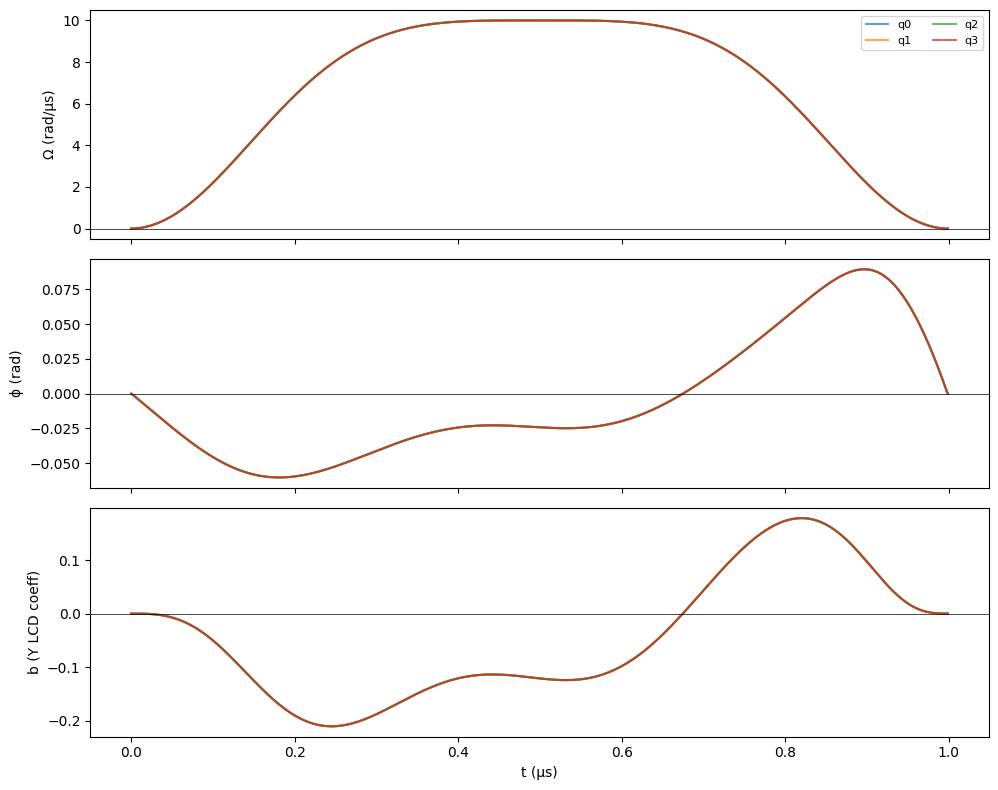

Ω(t=0)     = [7.61025885e-05+0.j 7.61025885e-05+0.j 7.61025885e-05+0.j
 7.61025885e-05+0.j]
Ω(t=end)   = [8.36664963e-05+0.j 8.36664963e-05+0.j 8.36664963e-05+0.j
 8.36664963e-05+0.j]
b(t=0)     = [-0. -0. -0. -0.]
b(t=end)   = [1.47455905e-34 1.47455905e-34 1.47455905e-34 1.47455905e-34]
ϕ(t=0)     = [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
ϕ(t=end)   = [3.52484952e-30+0.j 3.52484952e-30+0.j 3.52484952e-30+0.j
 3.52484952e-30+0.j]
Max |ϕ|    = 0.08952641715602848
Max |Δϕ|   = 0.0016482030306063417


In [8]:
def to_np(t):
    return t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.asarray(t)

import numpy as np
import matplotlib.pyplot as plt

t = np.arange(seq_data_lcd.omega.shape[0]) * dt / 1000  # μs
omega_lcd = to_np(seq_data_lcd.omega)
phi_lcd   = to_np(seq_data_lcd.phi)
b_lcd     = to_np(cd_lcd.b_history)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i in range(n_atoms):
    axes[0].plot(t, omega_lcd[:, i], alpha=0.7, label=f"q{i}")
    axes[1].plot(t, phi_lcd[:, i],   alpha=0.7)
    axes[2].plot(t, b_lcd[:, i],     alpha=0.7)
axes[0].set_ylabel("Ω (rad/μs)")
axes[1].set_ylabel("ϕ (rad)")
axes[2].set_ylabel("b (Y LCD coeff)")
axes[2].set_xlabel("t (μs)")
axes[0].legend(ncol=2, fontsize=8)
for ax in axes:
    ax.axhline(0, color='k', lw=0.5)
fig.tight_layout()
plt.show()

# Specifically check endpoints
print(f"Ω(t=0)     = {omega_lcd[0]}")
print(f"Ω(t=end)   = {omega_lcd[-1]}")
print(f"b(t=0)     = {b_lcd[0]}")
print(f"b(t=end)   = {b_lcd[-1]}")
print(f"ϕ(t=0)     = {phi_lcd[0]}")
print(f"ϕ(t=end)   = {phi_lcd[-1]}")
print(f"Max |ϕ|    = {np.abs(phi_lcd).max()}")
print(f"Max |Δϕ|   = {np.abs(np.diff(phi_lcd, axis=0)).max()}")  # jumps?

In [9]:
config = MPSConfig(
    dt=10,
    observables=[Fidelity(evaluation_times=[1.0], state=target),StateResult(evaluation_times=[1.0])])

print("Baseline schedule...")
backend = MPSBackend(seq, config=config)
results_baseline = backend.run()

emu-mps allows only {'occupation', 'correlation_matrix', 'energy', 'bitstrings', 'energy_second_moment', 'statistics', 'energy_variance'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'fidelity', 'state'} using `optimize_qubit_ordering = False` instead.
Baseline schedule...
emu-mps allows only {'occupation', 'correlation_matrix', 'energy', 'bitstrings', 'energy_second_moment', 'statistics', 'energy_variance'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'fidelity', 'state'} using `optimize_qubit_ordering = False` instead.
step = 1/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.031 s
step = 2/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.019 s
step = 3/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.022 s
step = 4/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.022 s
step = 5/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.025 s
step = 6/100, χ = 2, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.030 s
step = 

In [10]:
print("Emulating LCD schedule...")
results_lcd=MPSBackend._run_from_sequence_data(seq_data_lcd, config)


Emulating LCD schedule...
step = 1/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.016 s
step = 2/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s


step = 3/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 4/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 5/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 6/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 7/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 8/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 9/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 10/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 11/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 12/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 13/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 14/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 15/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 16/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 17/1000, χ = 1, |ψ| = 0.000 MB, RS

In [11]:
print("Emulating COLD schedule...")
results_cold=MPSBackend._run_from_sequence_data(seq_data_cold, config)

Emulating COLD schedule...
step = 1/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.016 s
step = 2/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 3/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 4/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 5/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 6/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 7/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 8/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 9/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 10/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 11/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 12/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 13/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 14/1000, χ = 1, |ψ| = 0.000 MB, RSS = 11.676 MB, Δt = 0.013 s
step = 15/1000, 

In [12]:
fid_baseline = results_baseline.get_tagged_results()['fidelity']
fid_lcd  = results_lcd.get_tagged_results()['fidelity']
fid_cold = results_cold.get_tagged_results()['fidelity']

print(f"Baseline  ground-state fidelity: {fid_baseline}")
print(f"LCD  ground-state fidelity: {fid_lcd}")
print(f"COLD ground-state fidelity: {fid_cold}")

Baseline  ground-state fidelity: [tensor(0.6438, dtype=torch.float64)]
LCD  ground-state fidelity: [tensor(0.5862, dtype=torch.float64)]
COLD ground-state fidelity: [tensor(0.5844, dtype=torch.float64)]


In [ ]:
print("max |a| (X, should be ≈ 0):", cd_cold.a_history.abs().max().item())
print("max |b| (Y, the applied LCD):", cd_cold.b_history.abs().max().item())
print("max |c| (Z, should be ≈ 0):", cd_cold.c_history.abs().max().item())

max |a| (X, should be ≈ 0): 0.0
max |b| (Y, the applied LCD): 2.0566050650237475
max |c| (Z, should be ≈ 0): 0.0


In [19]:
from pulser import Register
import networkx as nx

In [40]:
import numpy as np
import networkx as nx
from pulser import Register

def create_lattice_clusters_and_chains(
    n_clusters: int = 3,
    atoms_per_cluster: int = 7,  # Target number of atoms in the final cluster
    atoms_per_chain: int = 3,
    fill_fraction: float = 0.7,  # Proportion of sites kept (e.g., 70%)
    spacing: float = 5.0,
    seed: int | None = None
):
    """
    Generates a Pulser register of interconnected atomic clusters on a triangular lattice.
    Clusters are generated with random holes based on the fill_fraction.
    """
    rng = np.random.default_rng(seed)

    # The 6 nearest-neighbor directions on a triangular lattice grid (u, v)
    DIRS = [(1, 0), (0, 1), (-1, 1), (-1, 0), (0, -1), (1, -1)]

    def to_cartesian(u, v):
        """Converts discrete lattice coordinates to continuous XY plane."""
        x = (u + 0.5 * v) * spacing
        y = (v * np.sqrt(3) / 2) * spacing
        return x, y

    def get_base_patch(n_sites):
        """Creates a dense, roughly circular patch of lattice sites."""
        radius = int(np.sqrt(n_sites)) + 3
        candidates = []
        for du in range(-radius, radius + 1):
            for dv in range(-radius, radius + 1):
                x, y = to_cartesian(du, dv)
                candidates.append((x**2 + y**2, du, dv))
        candidates.sort() # Sort by distance from origin
        return [(u, v) for _, u, v in candidates[:n_sites]]

    # 1. Determine the size of the dense template needed
    dense_sites_needed = int(atoms_per_cluster / fill_fraction)
    dense_template = get_base_patch(dense_sites_needed)
    
    def sample_cluster():
        """Returns a cluster with holes by sampling the dense template."""
        indices = rng.choice(len(dense_template), size=atoms_per_cluster, replace=False)
        return [dense_template[i] for i in indices]

    # Initialize the first cluster
    c0 = sample_cluster()
    occupied = set(c0)
    clusters = [c0]
    chains = []

    # Iteratively attach new clusters
    for i in range(1, n_clusters):
        placed = False
        parents = list(range(i))
        rng.shuffle(parents) # Randomize which cluster we branch from

        for p in parents:
            if placed: break
            dirs = list(DIRS)
            rng.shuffle(dirs)

            for (du, dv) in dirs:
                parent_patch = clusters[p]
                
                # Projection function to find the furthest atom in a given direction
                dx, dy = to_cartesian(du, dv)
                def proj(u, v):
                    px, py = to_cartesian(u, v)
                    return px * dx + py * dy
                
                # Attachment atom on the parent (furthest in direction (du, dv))
                attach_p = max(parent_patch, key=lambda node: proj(node[0], node[1]))

                # Build the chain nodes
                chain_nodes = []
                for k in range(1, atoms_per_chain + 1):
                    chain_nodes.append((attach_p[0] + k * du, attach_p[1] + k * dv))
                
                chain_end = chain_nodes[-1] if chain_nodes else attach_p
                target_attach_c = (chain_end[0] + du, chain_end[1] + dv)

                # Sample a fresh child cluster with holes
                child_base = sample_cluster()

                # Attachment point on the child (furthest in OPPOSITE direction)
                attach_c_base = max(child_base, key=lambda node: proj(-node[0], -node[1]))

                # Shift the child cluster so its attachment point lands exactly on target
                shift_u = target_attach_c[0] - attach_c_base[0]
                shift_v = target_attach_c[1] - attach_c_base[1]
                shifted_patch = [(u + shift_u, v + shift_v) for u, v in child_base]

                # Collision check on the integer grid
                new_nodes = set(chain_nodes) | set(shifted_patch)
                if occupied.isdisjoint(new_nodes):
                    occupied.update(new_nodes)
                    chains.append(chain_nodes)
                    clusters.append(shifted_patch)
                    placed = True
                    break

        if not placed:
            raise RuntimeError("Could not place cluster! The layout became trapped. Try a different seed.")

    # Convert everything to cartesian coordinates for Pulser & NetworkX
    coords = {}
    node_idx = 0
    cluster_ids = []
    
    for cl in clusters:
        ids = []
        for (u, v) in cl:
            qid = f"q{node_idx}"
            coords[qid] = to_cartesian(u, v)
            ids.append(qid)
            node_idx += 1
        cluster_ids.append(ids)

    chain_ids = []
    for ch in chains:
        ids = []
        for (u, v) in ch:
            qid = f"q{node_idx}"
            coords[qid] = to_cartesian(u, v)
            ids.append(qid)
            node_idx += 1
        chain_ids.append(ids)

    reg = Register(coords)

    # Build NetworkX Graph (edges connect atoms separated by exactly `spacing`)
    G = nx.Graph()
    G.add_nodes_from(coords.keys())
    qids = list(coords.keys())
    for i in range(len(qids)):
        for j in range(i + 1, len(qids)):
            p1, p2 = np.array(coords[qids[i]]), np.array(coords[qids[j]])
            if np.linalg.norm(p1 - p2) < spacing * 1.05:
                G.add_edge(qids[i], qids[j])

    return reg, G, cluster_ids, chain_ids

In [41]:
reg, graph, cluster_ids, chain_ids = create_lattice_clusters_and_chains(
    n_clusters=4, 
    atoms_per_cluster=7, 
    atoms_per_chain=2, 
    spacing=5.0,
)

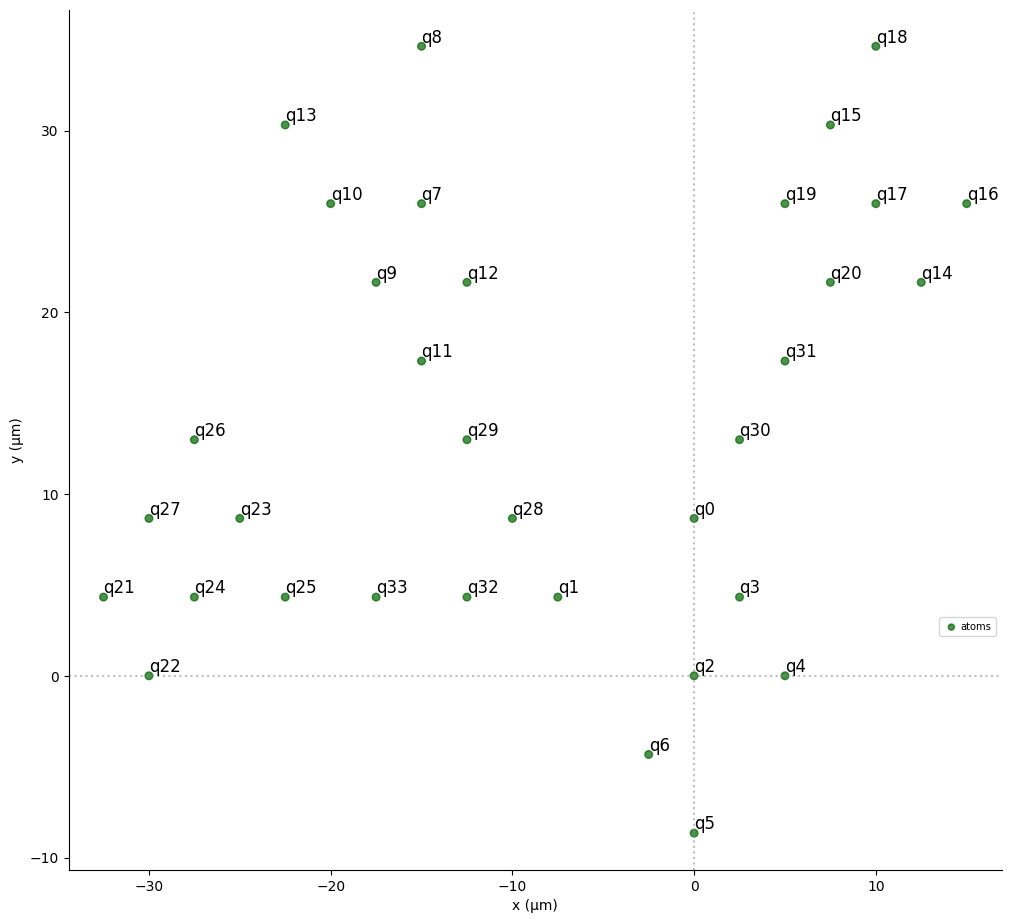

In [42]:
reg.draw()

In [1]:
import torch

In [4]:
from pulser import Register

In [1]:
from pulser.devices import AnalogDevice

In [2]:
AnalogDevice.channels['rydberg_global'].max_abs_detuning

125.66370614359172